# Sequence Context Analysis

**Does the local nucleotide sequence surrounding an edited adenosine differ from the background?**

This notebook addresses the following questions:

- Which nucleotides are enriched or depleted around edited adenosines?
- Are specific 3-mer, 5-mer, 7-mer, or longer sequence motifs preferred?
- Does the sequence context of edited adenosines differ from comparable unedited adenosines?
- Does sequence context differ between highly and weakly edited sites?

## Imports

In [1]:
import numpy as np # numerical operations.
import pandas as pd # loading, filtering, and analysing tabular data.
from pathlib import Path # operating-system-independent file path handling.
import matplotlib.pyplot as plt # plotting results.
from pyfaidx import Fasta # indexed access to the hg38 FASTA file.
from Bio.Seq import Seq # reverse-complement negative-strand sequences.

## Load the reference genome (hg38)

In [2]:
# pyfaidx creates or uses an existing FASTA index automatically
hg38 = Fasta("../data/hg38.fa")
# display the first chromosome name
print(list(hg38.keys()))

['chr1', 'chr10', 'chr11', 'chr11_KI270721v1_random', 'chr12', 'chr13', 'chr14', 'chr14_GL000009v2_random', 'chr14_GL000225v1_random', 'chr14_KI270722v1_random', 'chr14_GL000194v1_random', 'chr14_KI270723v1_random', 'chr14_KI270724v1_random', 'chr14_KI270725v1_random', 'chr14_KI270726v1_random', 'chr15', 'chr15_KI270727v1_random', 'chr16', 'chr16_KI270728v1_random', 'chr17', 'chr17_GL000205v2_random', 'chr17_KI270729v1_random', 'chr17_KI270730v1_random', 'chr18', 'chr19', 'chr1_KI270706v1_random', 'chr1_KI270707v1_random', 'chr1_KI270708v1_random', 'chr1_KI270709v1_random', 'chr1_KI270710v1_random', 'chr1_KI270711v1_random', 'chr1_KI270712v1_random', 'chr1_KI270713v1_random', 'chr1_KI270714v1_random', 'chr2', 'chr20', 'chr21', 'chr22', 'chr22_KI270731v1_random', 'chr22_KI270732v1_random', 'chr22_KI270733v1_random', 'chr22_KI270734v1_random', 'chr22_KI270735v1_random', 'chr22_KI270736v1_random', 'chr22_KI270737v1_random', 'chr22_KI270738v1_random', 'chr22_KI270739v1_random', 'chr2_KI270

## Load the dataset (REDIportal)

In [3]:
# load REDIportal dataset
REDIPORTAL_FILE = "../data/TABLE1_hg38_v3.txt"
df_raw = pd.read_csv(
    REDIPORTAL_FILE,
    sep="\t",
    low_memory=False,
)
# quick look at how the data looks like
df_raw

,Accession,Region,Position,Ref,Ed,Strand,db,type,dbsnp,repeat,...,rnacentral,nTCGASamples,nTCGAPrj,sTCGAprj,sTCGAdiseasetype,nTCGAdiseasetype,PlotsTCGA,PRIDE,REDInet_BS,REDInet_mean
0,EDHSAAAA0000,chr1,87158,T,C,-,A,ALU,-,SINE/AluJo,...,-,0.0,0.0,0,0,0.0,"0,0,0,0,0,0-0,0,0,0,0,0-0,0,0,0,0,0-0,0,0,0,0,...",-,"-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-...",-1.000000
1,EDHSAAAA0001,chr1,87168,T,C,-,A,ALU,-,SINE/AluJo,...,-,0.0,0.0,0,0,0.0,"0,0,0,0,0,0-0,0,0,0,0,0-0,0,0,0,0,0-0,0,0,0,0,...",-,"-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-...",-1.000000
2,EDHSAAAA0002,chr1,87171,T,C,-,A,ALU,-,SINE/AluJo,...,-,2.0,2.0,101000000000000000000,100000000001000000000000,2.0,"0,0,0,0,0,0-0,0,0,0,0,0-0,0,0,0,0,0-0,0,0,0,0,...",-,"-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-...",-1.000000
3,EDHSAAAA0003,chr1,87189,T,C,-,A,ALU,-,SINE/AluJo,...,-,0.0,0.0,0,0,0.0,"0,0,0,0,0,0-0,0,0,0,0,0-0,0,0,0,0,0-0,0,0,0,0,...",-,"-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-...",-1.000000
4,EDHSAAAA0004,chr1,87218,T,C,-,A,ALU,-,SINE/AluJo,...,-,1.0,1.0,10000000000,100000000000000000000000,1.0,"0,0,0,0,0,0-0,0,0,0,0,0-0,0,0,0,0,0-0,0,0,0,0,...",-,"-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-...",-1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
749921,EDHSAACW9921,chr1,88999255,T,C,-,A,ALU,-,SINE/AluJo,...,-,0.0,0.0,0,0,0.0,"0,0,0,0,0,0-0,0,0,0,0,0-0,0,0,0,0,0-0,0,0,0,0,...",-,"-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-...",-1.000000
749922,EDHSAACW9922,chr1,88999306,A,G,+,A,ALU,-,SINE/AluJo,...,-,2.0,2.0,10000001000000,100001000000000000000000,2.0,"0,0,0,0,0,0-0,0,0,0,0,0-0,0,0,0,0,0-0,0,0,0,0,...",-,"-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-...",1.000000
749923,EDHSAACW9923,chr1,88999314,T,C,-,A,ALU,-,SINE/AluJo,...,-,98.0,13.0,1010001010111010011000001010100,100001100001000000001001,6.0,"0,0,0,0,0,0-0.87,1.00,1.00,0.80,1.00,0.60-0,0,...",-,"-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-...",-1.000000
749924,EDHSAACW9924,chr1,88999320,A,G,+,A,ALU,-,SINE/AluJo,...,-,7.0,3.0,1000000000010000001000000,100001000000000000000000,2.0,"0,0,0,0,0,0-0,0,0,0,0,0-0,0,0,0,0,0-0,0,0,0,0,...",-,"-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-...",0.510722


### Explore the dataset
- Accession: A unique Accession Number
- Region: Chromosome
- Position: Genomic Coordinates
- Ref: Reference Nucleotide
- Ed: Edited Nucleodite
- Strand: Strand (+ or -)
- db: indicating whether the site was already known in previous editing databases (RADAR and DARNED)
- type: Editing location: ALU, REP, NONREP
- dbsnp: reference ID for dbSNP
- repeat: Class and family of repeat including the RNA editing position.
- Func: Function
- Gene: Gene name
- ExonicFunc: Exonic function according to gencode v45
- AAChange: RNA editing sites residing in protein coding regions and affecting codon integrity
- phastConsElements100way: ?? PhastCons conservation scores calculated for multiple alignments of 45 vertebrate genomes to the human genome; first number = Score (ranges from 0 (no conservation) to 1000 (max conservation)), second number = ?? 
- nSamples: number of GTEx samples 
- nTissues: number of GTEx tissues 
- sTissue: encoding of GTEx tissues 
- sBody: encoding of GTEx Body sites
- nBodySites: number of GTEx body sites
- PlotsBody: values (min, Q1, median, Q3, max) to plot the boxplot for each bodysite (GTEx)
- geneID: gene ID (ensembl)
- geneType: type of gene (ensembl)
- geneTag: Annotation Attributes (ensembl - https://www.gencodegenes.org/pages/tags.html)
- uniprotID: ID number from UniProt (database for protein sequence and functional information)
- rnacentral: ID for RNA central (but no result in RNA central)
- nTCGASamples: number of TCGA Samples
- nTCGAPrj: number of TCGA Studies 
- sTCGAprj: encoding of TCGA Studies 
- sTCGAdiseasetype: encoding of TCGA Diseases 
- nTCGAdiseasetype: number of TCGA Diseases
- PlotsTCGA: values (min, Q1, median, Q3, max) to plot the boxplot for each bodysite (TCGA)
- PRIDE: PRoteomics IDEntifications database entry
- REDInet_BS: REDInet Pvalue per Body Site
- REDInet_mean: mean of REDInet Pvalue over all Body Sites (-1 means no sample)


ANNOVAR for Gene, Func, ExonicFunc, AAChange,
- wgEncodeGencodeBasicV45: Gencode v45 Annotation linked to GeneCards (GENCODE)
- refGene: RefSeq Annotation (RefSeq database)
- knownGene: UCSC Annotation (UCSC Known Gene database)


Details <br>
AA change:
  - Gene Symbol
  - Ensembl Transcript ID
  - specific Exon where the edit occurs.
  - The Coding DNA change. c.A100G: unedited nt, position, edited nt
  - The Protein change. p.V861A: unedited AA, position, edited AA
  - example: PITRM1:ENST00000451104.6:exon22:c.T2582C:p.V861A,PITRM1:ENST00000678436.1:exon23:c.T2678C:p.V893A


not sure how nSamples and nTCGASamples are

### Display column names of the dataset

In [8]:
print("Column names: \n", df_raw.columns.tolist(), "\n")

# Show data types and missing values
print("Data types and missing values: \n")
df_raw.info()

Column names: 
 ['Accession', 'Region', 'Position', 'Ref', 'Ed', 'Strand', 'db', 'type', 'dbsnp', 'repeat', 'Func.wgEncodeGencodeBasicV45', 'Gene.wgEncodeGencodeBasicV45', 'ExonicFunc.wgEncodeGencodeBasicV45', 'AAChange.wgEncodeGencodeBasicV45', 'Func.refGene', 'Gene.refGene', 'ExonicFunc.refGene', 'AAChange.refGene', 'Func.knownGene', 'Gene.knownGene', 'ExonicFunc.knownGene', 'AAChange.knownGene', 'phastConsElements100way', 'nSamples', 'nTissues', 'sTissue', 'sBody', 'nBodySites', 'PlotsBody', 'geneID', 'geneType', 'geneTag', 'uniprotID', 'rnacentral', 'nTCGASamples', 'nTCGAPrj', 'sTCGAprj', 'sTCGAdiseasetype', 'nTCGAdiseasetype', 'PlotsTCGA', 'PRIDE', 'REDInet_BS', 'REDInet_mean'] 

Data types and missing values: 

<class 'pandas.DataFrame'>
RangeIndex: 749926 entries, 0 to 749925
Data columns (total 43 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   Accession                           

## Filter canonical A-to-I sites

A-to-I editing normally appears as :
- A to G on the (+) strand
- T to C on the (-) strand

The (-) strand sites must later be reverse-complemented => extrancted window is an RNA sequence with A at its center.

In [22]:
# Total A-to-I RNA editing sites

# Work on a copy
df_copy = df_raw.copy() 

# Display the observed reference-to-edited nucleotide combinations.
# This helps verify how REDIportal stores editing events on each strands
editing_changes = (
    df_copy
    .groupby(["Strand", "Region", "Ref", "Ed"], dropna=False) # group identical rows by strand, ref, ed. rows w missing values not discarded
    .size() # count how many sites are in each group (n_sites)
    .reset_index(name="n_sites") # convert the result back into a normal DataFrame, names "n_sites"
    .sort_values("n_sites", ascending=False) # sort the combinations in  descending order
)

print(editing_changes)
print(f"Total editing changes: {editing_changes['n_sites'].sum():,}")


  Strand Region Ref Ed  n_sites
0      +   chr1   A  G   393982
1      -   chr1   T  C   355944
Total editing changes: 749,926


In [23]:
# Filter canonical A-to-I sites

# Work on a copy so the original dataset is not modified.
df_copy = df_raw.copy()

# Standardise the relevant text columns.
for column in ["Region", "Ref", "Ed", "Strand"]:
    df_copy[column] = (
        sequence_df[column]
        .astype(str)
        .str.strip()
        .str.upper()
    )

# Convert genomic positions to numeric values.
df_copy["Position"] = pd.to_numeric(
    df_copy["Position"],
    errors="coerce",
)

# Remove rows without valid coordinates.
df_copy = df_copy.dropna(
    subset=["Region", "Position", "Ref", "Ed", "Strand"]
).copy()

# Convert valid positions to integers.
df_copy["Position"] = df_copy["Position"].astype(int)

In [24]:
# Positive-strand A-to-I editing appears as A > G.
positive_mask = (
    (df_copy["Strand"] == "+")
    & (df_copy["Ref"] == "A")
    & (df_copy["Ed"] == "G")
)

# Negative-strand A-to-I editing appears as T > C.
negative_mask = (
    (df_copy["Strand"] == "-")
    & (df_copy["Ref"] == "T")
    & (df_copy["Ed"] == "C")
)

# Retain canonical A-to-I sites.
canonical_df = df_copy[
    positive_mask | negative_mask
].copy()

canonical_df.reset_index(drop=True, inplace=True)

print(f"Canonical A-to-I sites: {len(canonical_df):,}")
print(canonical_df["Strand"].value_counts())

Canonical A-to-I sites: 749,926
Strand
+    393982
-    355944
Name: count, dtype: int64


**Observations**

All edit sites in the dataset are canonical.

The dataset shows 2 types of edit sites:
1. A-to-G on the (+) strand (direct edit sites)
2. T-to-C on the (-) strand (complementary edit sites)

The A-to-G sites actually represent A-to-I edited sites performed by ADAR in eukaryote cells. Inosines are interpreted as guanosine during sequencing, hence the change.
A-to-I edits occur approximately in the same amount on both positive and negative strands.

## Kmer analysis

### Kmer analysis functions

In [47]:
sequence = "ATGCGCTANN"

def reverse_complement(sequence: str) -> str:
    """
    Reverse complements a genomic strand.

    Parameters
        sequence : str
            input DNA sequence
    
    Return
        str
            reverse-complementary DNA sequence
    """

    rev_seq = reversed(sequence)
    rev_comp_seq = ""

    compl_nucleotides = {
        "A":"T",
        "T":"A",
        "G":"C",
        "C":"G",
        "N": "N",
    }

    return "".join(compl_nucleotides[ch] for ch in rev_seq)

print(reverse_complement(sequence))

NNTAGCGCAT


In [89]:
def extract_one_centered_kmer(k: int, genome: str, chromosome: str, position_1based: int, strand: str) -> str | None:
    """
    Extract an odd-length k-mer centred on an editing site.
    REDIportal genomic positions are one-based.
    The returned seq is converted to transcript orientation (5' -> 3').
    
    Parameters
        k: int
            length of the kmer
        genome: str
            Indexed hg38 reference genome
        chromosome: str 
            chromosome name, such as "chr1"
        position_1based: int 
            one-based genomic editing position
        strand: str
            genomic strand "+" or "-"
    
    Returns
        str or None
            transcript-oriented kmer centered on the edited A
    """

    # kmer len needs to be odd for a centered_kmer
    if k % 2 == 0 or k <= 0 or not isinstance(k, int):
        raise VelueError("k must be a positive odd integer.")

    # convert one-based into 0-based
    center_0based = position_1based - 1

    # calculated how many nucleotides are needed on each side
    flank_size = k // 2

    # pyfaidx uses end-exclusive splicing
    start = center_0based - flank_size 
    end = center_0based + flank_size + 1

    # negative starting position is outside of the chromosome
    if start < 0:
        return None

    try:
        # Extract the sequence in reference-genome orientation
        sequence = str(genome[chromosome][start:end]).upper()

    except (KeyError):
        return "Invalid chromosome name"
    
    except (ValueError):
        return "Invalid coordinates"

    # extracted length must equel k
    if len(sequence) != k:
        return None 

    # convert negative-stranded kmers to transcript orientation
    if strand == "-":
        sequence = reverse_complement(sequence)
    
    return sequence

print(extract_one_centered_kmer(7, hg38, "chr1", 88999324, "-"))


GGAAGGC


**Observation**

7-mer A-to-I edit sites from the very beginning and end of hg38 often have the pattern:
- beginning: TCCAGCC, ACCACTG, CACACCA, GCCACAG, GGTAGGA, 
- end: TGCACTC, AGCAGTC, GGCAGGA, CTCAGCC, GGAAGGC

Mostly C at position -1, G or C at position 1


In [90]:
def extract_all_kmers(
    dataframe: pd.DataFrame,
    genome,
    k: int,
    output_file: str | None = None,
    chromosome_column: str = "Region",
    position_column: str = "Position",
    strand_column: str = "Strand",
) -> pd.DataFrame:
    """
    Extract centered k-mers for all editing sites in a DataFrame.

    The resulting table contains the original site information,
    the extracted k-mer, and a validation flag.

    Parameters
    ----------
    dataframe : pandas.DataFrame
        Editing-site table.

    genome
        Indexed reference genome loaded with pyfaidx.

    k : int
        Desired odd k-mer length.

    output_file : str or None
        Optional TSV file path for saving the extracted sequences.

    chromosome_column : str
        Name of the chromosome column.

    position_column : str
        Name of the genomic-position column.

    strand_column : str
        Name of the strand column.

    Returns
    -------
    pandas.DataFrame
        Table containing one row per editing site and its extracted k-mer.
    """

    # Validate k before starting extraction.
    if not isinstance(k, int) or k <= 0 or k % 2 == 0:
        raise ValueError(
            "k must be a positive odd integer."
        )

    # Check that the required columns exist.
    required_columns = {
        chromosome_column,
        position_column,
        strand_column,
    }

    missing_columns = required_columns.difference(dataframe.columns)

    if missing_columns:
        raise KeyError(
            f"Missing required columns: {sorted(missing_columns)}"
        )

    # Keep only useful site-identification columns when available.
    preferred_columns = [
        "Accession",
        chromosome_column,
        position_column,
        "Ref",
        "Ed",
        strand_column,
        "type",
        "repeat",
        "Func",
        "Gene",
    ]

    selected_columns = [
        column
        for column in preferred_columns
        if column in dataframe.columns
    ]

    # Work on a compact copy of the editing-site table.
    result_df = dataframe[selected_columns].copy()

    # Store all extracted sequences in this list.
    kmers = []

    # Iterate through every editing site.
    for chromosome, position, strand in dataframe[
        [
            chromosome_column,
            position_column,
            strand_column,
        ]
    ].itertuples(index=False, name=None):

        kmer = extract_one_centered_kmer(
            genome=genome,
            chromosome=str(chromosome),
            position_1based=int(position),
            strand=str(strand),
            k=k,
        )

        kmers.append(kmer)

    # Add the sequence column.
    sequence_column = f"sequence_{k}mer"
    result_df[sequence_column] = kmers

    # Extract the central nucleotide for validation.
    center_index = k // 2

    result_df["center_base"] = (
        result_df[sequence_column]
        .str[center_index]
    )

    # Mark complete A-centered DNA sequences as valid.
    flank_size = k // 2

    valid_pattern = (
        rf"[ACGT]{{{flank_size}}}"
        rf"A"
        rf"[ACGT]{{{flank_size}}}"
    )

    result_df["valid_kmer"] = (
        result_df[sequence_column]
        .fillna("")
        .str.fullmatch(valid_pattern)
    )

    # Print a short extraction report.
    n_total = len(result_df)
    n_extracted = result_df[sequence_column].notna().sum()
    n_valid = result_df["valid_kmer"].sum()

    print(f"Requested k-mer length: {k}")
    print(f"Total editing sites: {n_total:,}")
    print(f"Successfully extracted: {n_extracted:,}")
    print(f"Valid A-centered k-mers: {n_valid:,}")
    print(f"Invalid or failed: {n_total - n_valid:,}")

    # Save the table when an output path was provided.
    if output_file is not None:
        result_df.to_csv(
            output_file,
            sep="\t",
            index=False,
        )

        print(f"Saved extracted k-mers to: {output_file}")

    return result_df


In [101]:
def count_kmers_from_file(
    input_file: str,
    k: int,
    valid_only: bool = True,
) -> pd.DataFrame:
    """
    Load an extracted k-mer table and count motif frequencies.

    Parameters
    ----------
    input_file : str
        Path to the TSV file created by extract_all_kmers().

    k : int
        K-mer length represented in the file.

    valid_only : bool
        Whether to count only validated A-centered k-mers.

    Returns
    -------
    pandas.DataFrame
        Motif counts and percentages.
    """

    # Load the extracted k-mer table.
    kmer_df = pd.read_csv(
        input_file,
        sep="\t",
        low_memory=False,
    )

    # Determine the expected sequence-column name.
    sequence_column = f"sequence_{k}mer"

    if sequence_column not in kmer_df.columns:
        raise KeyError(
            f"Expected column '{sequence_column}' was not found."
        )

    # Retain only validated sequences when requested.
    if valid_only:
        if "valid_kmer" not in kmer_df.columns:
            raise KeyError(
                "The file does not contain a 'valid_kmer' column."
            )

        kmer_df = kmer_df[
            kmer_df["valid_kmer"] == True
        ].copy()

    # Count each distinct motif.
    frequency_df = (
        kmer_df[sequence_column]
        .value_counts()
        .rename_axis("kmer")
        .reset_index(name="n_sites")
    )

    # Calculate relative frequencies.
    frequency_df["percentage"] = (
        frequency_df["n_sites"]
        / frequency_df["n_sites"].sum()
        * 100
    )

    return frequency_df

In [114]:
def plot_kmer_percentages(
    frequency_df: pd.DataFrame,
    k: int,
    top_n: int = 20,
    save_file: str | None = None,
) -> None:
    """
    Plot the most frequent k-mer motifs using percentages.

    Parameters
    ----------
    frequency_df : pandas.DataFrame
        Frequency table containing "kmer" and "percentage".

    k : int
        Length of the motifs.

    top_n : int
        Number of motifs to plot.

    save_file : str or None
        Optional figure output path.
    """

    # Select and sort the most frequent motifs.
    plot_df = (
        frequency_df
        .sort_values(
            "percentage",
            ascending=False,
        )
        .head(top_n)
        .sort_values(
            "percentage",
            ascending=True,
        )
        .copy()
    )

    figure_height = max(5, top_n * 0.35)

    plt.figure(
        figsize=(9, figure_height)
    )

    plt.barh(
        plot_df["kmer"],
        plot_df["percentage"],
    )

    plt.xlabel("Percentage of editing sites (%)")
    plt.ylabel(f"{k}-mer motif")
    plt.title(
        f"Top {len(plot_df)} Most Frequent "
        f"{k}-mer Motifs Around Edited Adenosines"
    )

    plt.tight_layout()

    if save_file is not None:
        plt.savefig(
            save_file,
            dpi=300,
            bbox_inches="tight",
        )

        print(f"Figure saved to: {save_file}")

    plt.show()

### 3-mer analysis

In [94]:
three_mer_file = (
    Path.cwd().parent
    /"results" 
    /"01_sequence_context"
    /"3mers.tsv"
)

print(extract_all_kmers(dataframe=df_raw, genome=hg38, k=3, output_file=three_mer_file,))

Requested k-mer length: 3
Total editing sites: 749,926
Successfully extracted: 749,926
Valid A-centered k-mers: 749,880
Invalid or failed: 46
Saved extracted k-mers to: /home/mescalin/bioinf/rna_editing_project/results/01_sequence_context/3mers.tsv
           Accession Region  Position Ref Ed Strand type      repeat  \
0       EDHSAAAA0000   chr1     87158   T  C      -  ALU  SINE/AluJo   
1       EDHSAAAA0001   chr1     87168   T  C      -  ALU  SINE/AluJo   
2       EDHSAAAA0002   chr1     87171   T  C      -  ALU  SINE/AluJo   
3       EDHSAAAA0003   chr1     87189   T  C      -  ALU  SINE/AluJo   
4       EDHSAAAA0004   chr1     87218   T  C      -  ALU  SINE/AluJo   
...              ...    ...       ...  .. ..    ...  ...         ...   
749921  EDHSAACW9921   chr1  88999255   T  C      -  ALU  SINE/AluJo   
749922  EDHSAACW9922   chr1  88999306   A  G      +  ALU  SINE/AluJo   
749923  EDHSAACW9923   chr1  88999314   T  C      -  ALU  SINE/AluJo   
749924  EDHSAACW9924   chr1  88

In [102]:
three_mer_counts = count_kmers_from_file(
    input_file=three_mer_file,
    k=3,
)

three_mer_counts

,kmer,n_sites,percentage
0,CAG,117467,15.664773
1,CAC,67900,9.054782
2,GAG,65441,8.726863
3,AAA,60310,8.042620
4,TAG,58870,7.850589
5,CAA,53990,7.199819
6,AAG,53967,7.196751
7,AAT,47419,6.323545
8,TAC,44168,5.890009
9,AAC,39322,5.243772


Figure saved to: ../figures/most_frequent_3mer_motifs.png


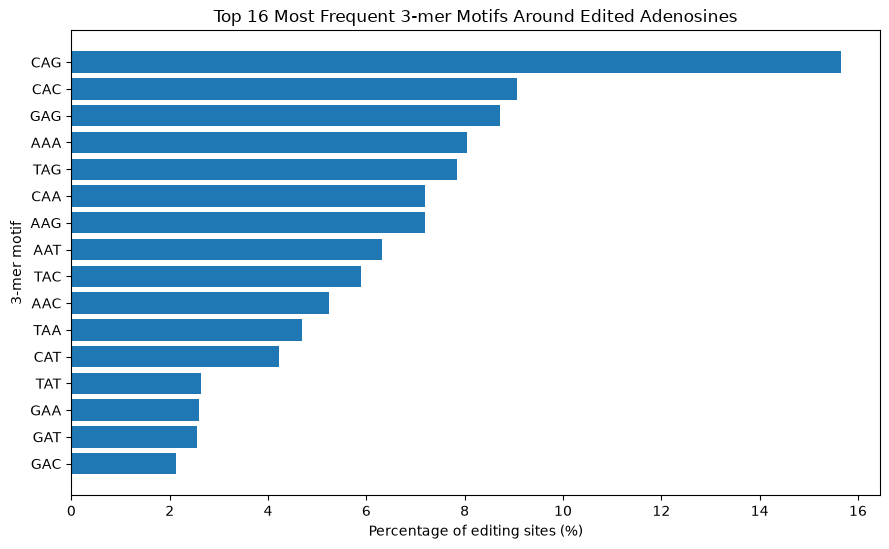

In [118]:
plot_kmer_percentages(
    frequency_df=three_mer_counts,
    k=3,
    top_n=16,
    save_file="../figures/most_frequent_3mer_motifs.png",
)

### 5-mer analysis

In [97]:
five_mer_file = (
    Path.cwd().parent
    /"results" 
    /"01_sequence_context"
    /"5mers.tsv"
)

print(extract_all_kmers(dataframe=df_raw, genome=hg38, k=5, output_file=five_mer_file,))

Requested k-mer length: 5
Total editing sites: 749,926
Successfully extracted: 749,926
Valid A-centered k-mers: 749,880
Invalid or failed: 46
Saved extracted k-mers to: /home/mescalin/bioinf/rna_editing_project/results/01_sequence_context/5mers.tsv
           Accession Region  Position Ref Ed Strand type      repeat  \
0       EDHSAAAA0000   chr1     87158   T  C      -  ALU  SINE/AluJo   
1       EDHSAAAA0001   chr1     87168   T  C      -  ALU  SINE/AluJo   
2       EDHSAAAA0002   chr1     87171   T  C      -  ALU  SINE/AluJo   
3       EDHSAAAA0003   chr1     87189   T  C      -  ALU  SINE/AluJo   
4       EDHSAAAA0004   chr1     87218   T  C      -  ALU  SINE/AluJo   
...              ...    ...       ...  .. ..    ...  ...         ...   
749921  EDHSAACW9921   chr1  88999255   T  C      -  ALU  SINE/AluJo   
749922  EDHSAACW9922   chr1  88999306   A  G      +  ALU  SINE/AluJo   
749923  EDHSAACW9923   chr1  88999314   T  C      -  ALU  SINE/AluJo   
749924  EDHSAACW9924   chr1  88

In [103]:
five_mer_counts = count_kmers_from_file(
    input_file=five_mer_file,
    k=5,
)

five_mer_counts

,kmer,n_sites,percentage
0,CCAGC,20247,2.700032
1,CCAGG,19757,2.634688
2,TCAGC,12949,1.726810
3,AAAAA,12779,1.704139
4,TAATC,12248,1.633328
...,...,...,...
251,GGACG,135,0.018003
252,GGATA,130,0.017336
253,TAACG,111,0.014802
254,CGACG,39,0.005201


Figure saved to: ../figures/most_frequent_5mer_motifs.png


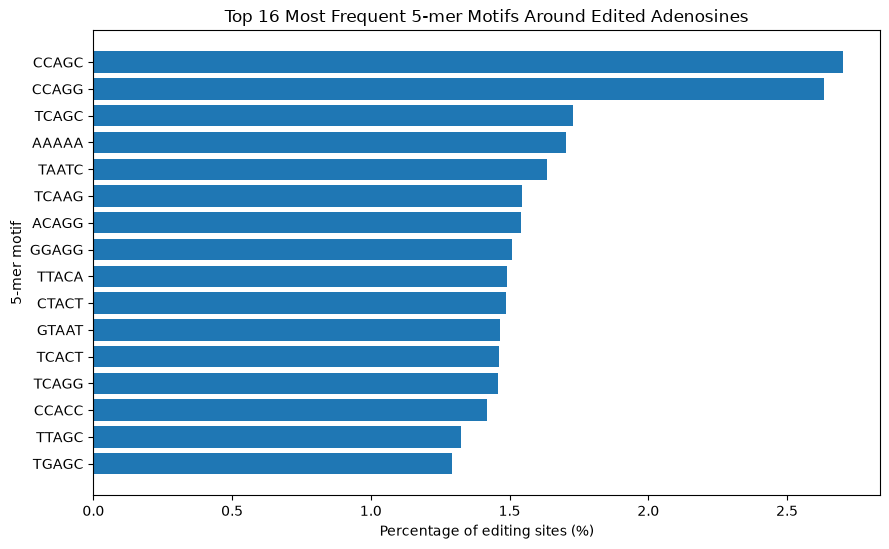

In [119]:
plot_kmer_percentages(
    frequency_df=five_mer_counts,
    k=5,
    top_n=16,
    save_file="../figures/most_frequent_5mer_motifs.png",
)

### 7-mer analysis

In [98]:
seven_mer_file = (
    Path.cwd().parent
    /"results" 
    /"01_sequence_context"
    /"7mers.tsv"
)

print(extract_all_kmers(dataframe=df_raw, genome=hg38, k=7, output_file=seven_mer_file,))

Requested k-mer length: 7
Total editing sites: 749,926
Successfully extracted: 749,926
Valid A-centered k-mers: 749,880
Invalid or failed: 46
Saved extracted k-mers to: /home/mescalin/bioinf/rna_editing_project/results/01_sequence_context/7mers.tsv
           Accession Region  Position Ref Ed Strand type      repeat  \
0       EDHSAAAA0000   chr1     87158   T  C      -  ALU  SINE/AluJo   
1       EDHSAAAA0001   chr1     87168   T  C      -  ALU  SINE/AluJo   
2       EDHSAAAA0002   chr1     87171   T  C      -  ALU  SINE/AluJo   
3       EDHSAAAA0003   chr1     87189   T  C      -  ALU  SINE/AluJo   
4       EDHSAAAA0004   chr1     87218   T  C      -  ALU  SINE/AluJo   
...              ...    ...       ...  .. ..    ...  ...         ...   
749921  EDHSAACW9921   chr1  88999255   T  C      -  ALU  SINE/AluJo   
749922  EDHSAACW9922   chr1  88999306   A  G      +  ALU  SINE/AluJo   
749923  EDHSAACW9923   chr1  88999314   T  C      -  ALU  SINE/AluJo   
749924  EDHSAACW9924   chr1  88

In [104]:
seven_mer_counts = count_kmers_from_file(
    input_file=seven_mer_file,
    k=7,
)

seven_mer_counts

,kmer,n_sites,percentage
0,GTAATCC,9584,1.278071
1,ATTACAG,9359,1.248066
2,TGTAATC,9228,1.230597
3,CTCAGCC,8132,1.084440
4,AGTAGCT,7112,0.948418
...,...,...,...
4064,ACGAATA,1,0.000133
4065,CCGATAC,1,0.000133
4066,TATATCG,1,0.000133
4067,CGTAGAA,1,0.000133


Figure saved to: ../figures/most_frequent_7mer_motifs.png


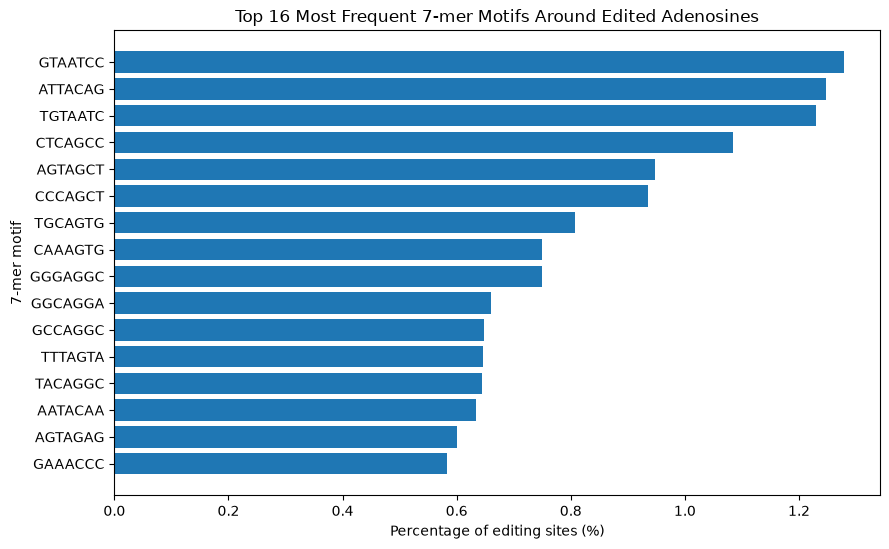

In [120]:
plot_kmer_percentages(
    frequency_df=seven_mer_counts,
    k=7,
    top_n=16,
    save_file="../figures/most_frequent_7mer_motifs.png",
)

### 15-mer analysis

In [105]:
fiveteen_mer_file = (
    Path.cwd().parent
    /"results" 
    /"01_sequence_context"
    /"15mers.tsv"
)

print(extract_all_kmers(dataframe=df_raw, genome=hg38, k=15, output_file=fiveteen_mer_file,))

Requested k-mer length: 15
Total editing sites: 749,926
Successfully extracted: 749,926
Valid A-centered k-mers: 749,880
Invalid or failed: 46
Saved extracted k-mers to: /home/mescalin/bioinf/rna_editing_project/results/01_sequence_context/15mers.tsv
           Accession Region  Position Ref Ed Strand type      repeat  \
0       EDHSAAAA0000   chr1     87158   T  C      -  ALU  SINE/AluJo   
1       EDHSAAAA0001   chr1     87168   T  C      -  ALU  SINE/AluJo   
2       EDHSAAAA0002   chr1     87171   T  C      -  ALU  SINE/AluJo   
3       EDHSAAAA0003   chr1     87189   T  C      -  ALU  SINE/AluJo   
4       EDHSAAAA0004   chr1     87218   T  C      -  ALU  SINE/AluJo   
...              ...    ...       ...  .. ..    ...  ...         ...   
749921  EDHSAACW9921   chr1  88999255   T  C      -  ALU  SINE/AluJo   
749922  EDHSAACW9922   chr1  88999306   A  G      +  ALU  SINE/AluJo   
749923  EDHSAACW9923   chr1  88999314   T  C      -  ALU  SINE/AluJo   
749924  EDHSAACW9924   chr1  

In [106]:
fiveteen_mer_counts = count_kmers_from_file(
    input_file=fiveteen_mer_file,
    k=15,
)

fiveteen_mer_counts

,kmer,n_sites,percentage
0,GCCTGTAATCCCAGC,4138,0.551822
1,CTCCCAAAGTGCTGG,3141,0.418867
2,TATTTTTAGTAGAGA,2932,0.390996
3,CTGAGGCAGGAGAAT,2820,0.376060
4,TAATCCCAGCACTTT,2447,0.326319
...,...,...,...
229134,CACCAAAAAGCTAAT,1,0.000133
229135,ACCAAAAAGCTAATC,1,0.000133
229136,ATAACCAATAGGCTT,1,0.000133
229137,AACCAATAGGCTTTA,1,0.000133


Figure saved to: ../figures/most_frequent_15mer_motifs.png


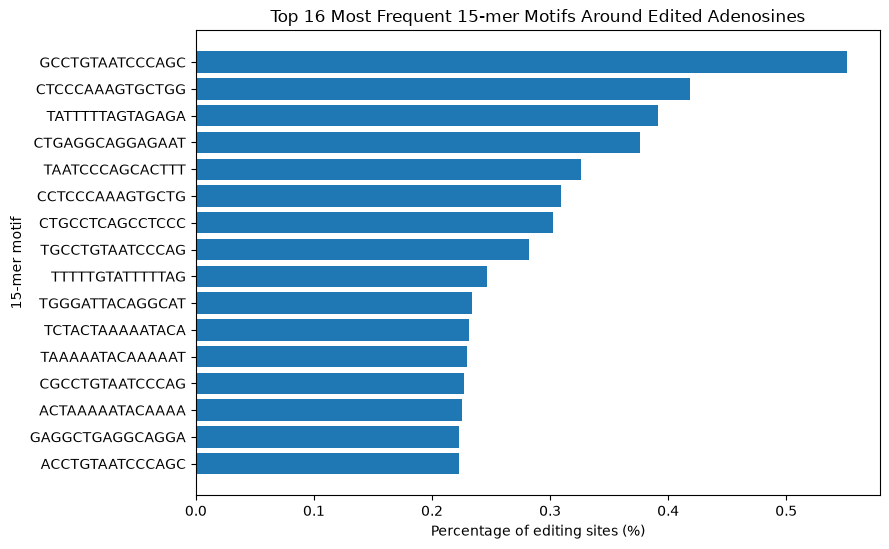

In [121]:
plot_kmer_percentages(
    frequency_df=fiveteen_mer_counts,
    k=15,
    top_n=16,
    save_file="../figures/most_frequent_15mer_motifs.png",
)

# Discussion

- What are important cis-regulatory elements in ch01 in humans?

- can primary sequence predict bboth seq sites and level?